# Parcial 3 - DT6
Solución base con random_state=20231085

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

datos = pd.read_csv('Parcial 3 - DT6.csv')
datos.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


In [2]:
le = LabelEncoder()

for col in ['day_type','after_hours_work','burnout_risk']:
    datos[col] = le.fit_transform(datos[col])

datos.info()
datos.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   int64  
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 154.8 KB


,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,90.500000,0.513333,6.515117,9.271406,1.941111,3.028889,0.358889,6.996467,72.308556,44.009978,1.129444
std,51.975162,0.499961,2.290521,2.409253,1.696178,1.417844,0.479808,1.061740,14.978647,23.881782,0.367404
min,1.000000,0.000000,3.000000,4.510000,0.000000,1.000000,0.000000,4.500000,40.000000,2.500000,0.000000
25%,45.750000,0.000000,4.430000,7.240000,1.000000,2.000000,0.000000,6.280000,62.300000,25.370000,1.000000
50%,90.500000,1.000000,6.445000,9.210000,2.000000,3.000000,0.000000,6.990000,74.500000,39.270000,1.000000
75%,135.250000,1.000000,8.510000,11.310000,3.000000,4.000000,1.000000,7.750000,83.700000,58.197500,1.000000
max,180.000000,1.000000,12.170000,15.700000,10.000000,5.000000,1.000000,10.800000,107.200000,143.920000,2.000000


## Análisis gráfico

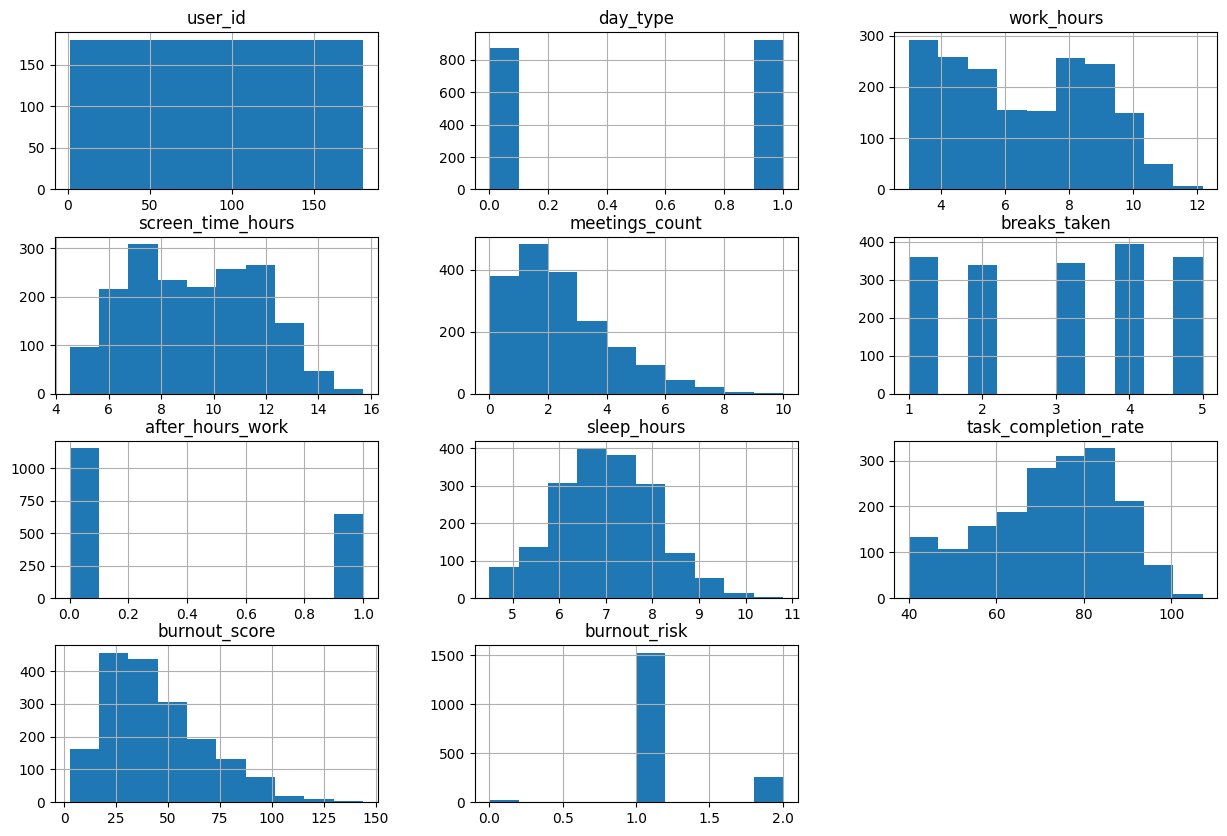

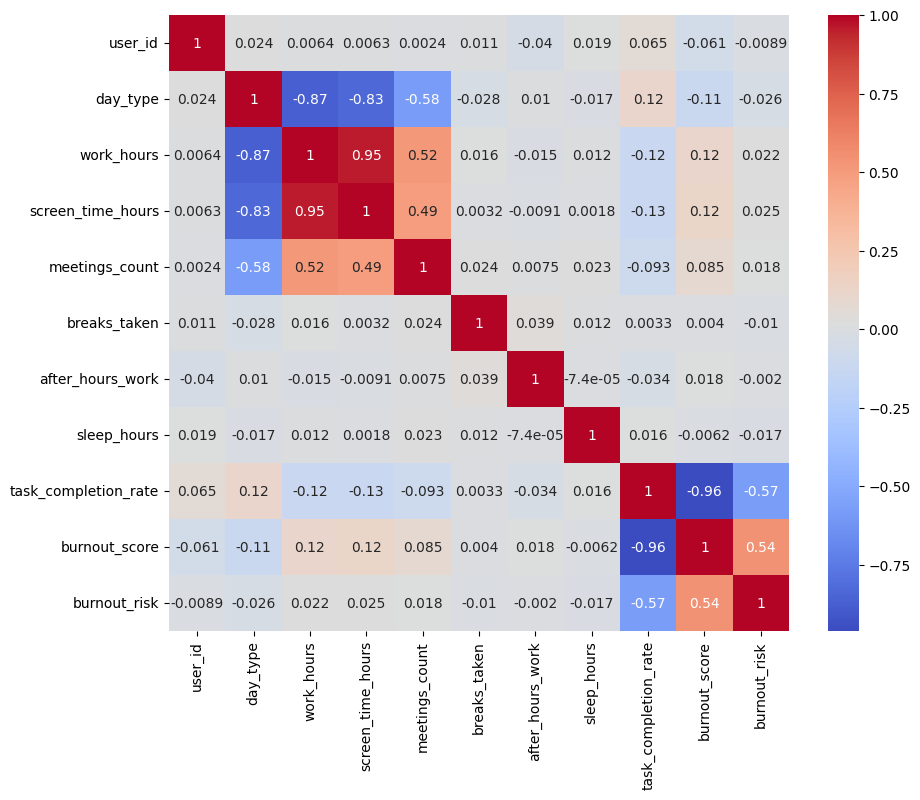

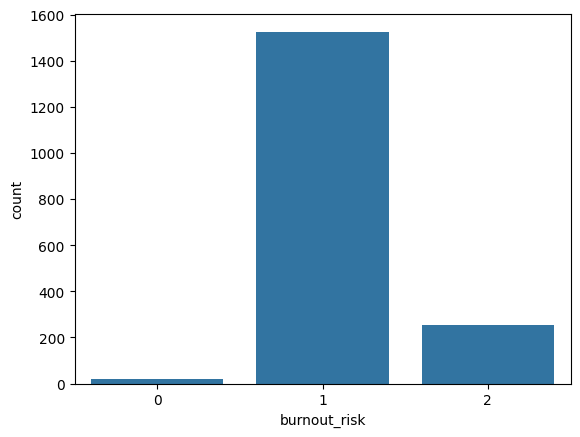

In [3]:
datos.hist(figsize=(15,10))
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(datos.corr(), annot=True, cmap='coolwarm')
plt.show()

sns.countplot(x='burnout_risk', data=datos)
plt.show()

In [4]:
X = datos.drop('burnout_risk', axis=1)
y = datos['burnout_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=20231085,
    stratify=y
)

## KNN con 2 variables

In [5]:
X_knn = datos[['burnout_score','sleep_hours']]
y = datos['burnout_risk']

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn, y,
    test_size=0.20,
    random_state=20231085,
    stratify=y
)

scores=[]
for k in range(1,50):
    modelo = KNeighborsClassifier(n_neighbors=k)
    cv = cross_val_score(modelo,X_train_knn,y_train_knn,cv=10,scoring='accuracy')
    scores.append(cv.mean())

best_k = np.argmax(scores)+1
print(best_k)

7


## KNN todas las variables

In [6]:
scores=[]
for k in range(1,50):
    modelo = KNeighborsClassifier(n_neighbors=k)
    cv = cross_val_score(modelo,X_train,y_train,cv=10,scoring='accuracy')
    scores.append(cv.mean())

best_k_all = np.argmax(scores)+1
print(best_k_all)

1


## Árbol de decisión

In [7]:
tree = DecisionTreeClassifier(
    min_samples_leaf=100,
    random_state=20231085
)

tree.fit(X_train,y_train)
pred_tree = tree.predict(X_test)

print('Accuracy:', accuracy_score(y_test,pred_tree))

Accuracy: 0.9888888888888889


## Ensambles

In [8]:
bag = BaggingClassifier(
    n_estimators=300,
    bootstrap=True,
    random_state=20231085
)

bag.fit(X_train,y_train)
print('Bagging:',accuracy_score(y_test,bag.predict(X_test)))

pasting = BaggingClassifier(
    n_estimators=300,
    bootstrap=False,
    random_state=20231085
)

pasting.fit(X_train,y_train)
print('Pasting:',accuracy_score(y_test,pasting.predict(X_test)))

rf = RandomForestClassifier(
    n_estimators=300,
    max_leaf_nodes=8,
    random_state=20231085
)

rf.fit(X_train,y_train)
print('Random Forest:',accuracy_score(y_test,rf.predict(X_test)))

Bagging: 1.0
Pasting: 1.0
Random Forest: 0.9972222222222222


In [9]:
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    random_state=20231085
)

gb.fit(X_train,y_train)
print('Gradient Boosting:',accuracy_score(y_test,gb.predict(X_test)))

Gradient Boosting: 1.0


## Predicción con la moda

In [10]:
nueva_persona = pd.DataFrame([X.mode().iloc[0]])
prediccion = rf.predict(nueva_persona)

print('Nivel de riesgo:', prediccion)

Nivel de riesgo: [1]
